In [2]:
import pandas as pd
import requests
from tqdm import tqdm
import time
from Bio import AlignIO
import numpy as np
from collections import Counter
import math

In [2]:
# === 1. 读取Excel ===
file_path = "./ncbiblast-WIL_PLA.xlsx"
df = pd.read_excel(file_path)

# 提取Accession列
uniprot_ids = df["Accession"].dropna().unique().tolist()

# === 2. 批量获取序列（UniProt API）===
def fetch_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            fasta = r.text
            seq = "".join(fasta.split("\n")[1:])
            return seq, fasta
        else:
            return None, None
    except:
        return None, None

seq_dict = {}
fasta_list = []

print("开始下载序列...")
for uid in tqdm(uniprot_ids):
    seq, fasta = fetch_sequence(uid)
    if seq:
        seq_dict[uid] = seq
        fasta_list.append(fasta)
    else:
        seq_dict[uid] = None
    time.sleep(0.2)  # 防止被封

# === 3. 写入FASTA文件 ===
with open("PLA_sequences.fasta", "w") as f:
    for fasta in fasta_list:
        f.write(fasta)

print("FASTA文件已生成：PLA_sequences.fasta")

# === 4. 回填Excel序列列 ===
df["Sequence"] = df["Accession"].map(seq_dict)

# 保存新文件
df.to_excel("ncbiblast_with_sequence.xlsx", index=False)

print("Excel已更新：ncbiblast_with_sequence.xlsx")

开始下载序列...


100%|██████████| 250/250 [09:58<00:00,  2.40s/it]

FASTA文件已生成：PLA_sequences.fasta
Excel已更新：ncbiblast_with_sequence.xlsx


## Step 1：计算每个位点 entropy（核心）

In [3]:
from Bio import AlignIO
import numpy as np
from collections import Counter
import math

alignment = AlignIO.read("PLA_3k_aligned.aln", "clustal")

def entropy(column):
    counts = Counter(column)
    total = sum(counts.values())
    H = 0
    for aa in counts:
        if aa == '-':  # 可选：忽略gap
            continue
        p = counts[aa] / total
        H -= p * math.log2(p)
    return H

entropy_list = []

for i in range(alignment.get_alignment_length()):
    col = alignment[:, i]
    entropy_list.append(entropy(col))

entropy_array = np.array(entropy_list)

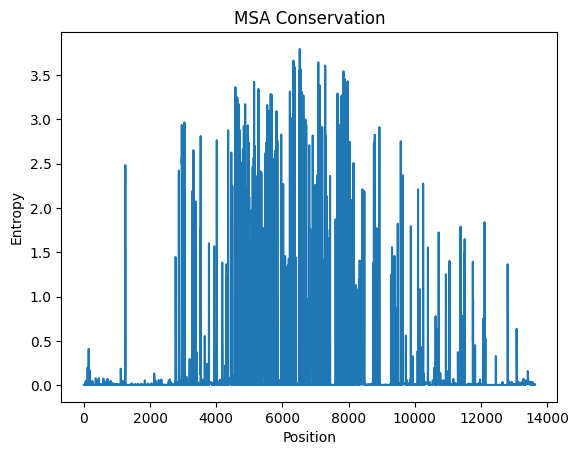

In [7]:
import matplotlib.pyplot as plt

plt.plot(entropy_array)
plt.xlabel("Position")
plt.ylabel("Entropy")
plt.title("MSA Conservation")
plt.show()

In [15]:
import numpy as np
from Bio import AlignIO
from collections import Counter
import math
import pandas as pd

# ==============================
# Step 1: 读取MSA
# ==============================
alignment = AlignIO.read("PLA_3k_aligned.aln", "clustal")

print("序列数:", len(alignment))
print("alignment长度:", alignment.get_alignment_length())

# 目标序列（默认第一条是WT）
target_seq = alignment[0].seq

# ==============================
# Step 2: 计算entropy
# ==============================
def shannon_entropy(column):
    counts = Counter(column)
    total = sum(counts.values())

    entropy = 0
    for aa in counts:
        if aa == '-':  # 忽略gap
            continue
        p = counts[aa] / total
        entropy -= p * math.log2(p)

    return entropy

entropy_list = []

for i in range(alignment.get_alignment_length()):
    column = alignment[:, i]
    entropy_list.append(shannon_entropy(column))

entropy_array = np.array(entropy_list)

# ==============================
# Step 3: 建立 alignment → 真实序列映射
# ==============================
mapping = {}
real_pos = 0

for i, aa in enumerate(target_seq):
    if aa != '-':
        real_pos += 1
        mapping[i] = real_pos

print("真实序列长度:", real_pos)

# ==============================
# Step 4: 计算每个位点的氨基酸分布
# ==============================
aa_distribution = []

for i in range(alignment.get_alignment_length()):
    column = alignment[:, i]
    counts = Counter(column)

    # 去掉gap
    if '-' in counts:
        del counts['-']

    aa_distribution.append(counts)

# ==============================
# Step 5: 筛选高entropy位点
# ==============================

threshold = 1.5  # 可以调（1.5~2.0）

candidate_sites = []

#for i, H in enumerate(entropy_array):
 #   if H > threshold and i in mapping:

for i, H in enumerate(entropy_array):
    if i in mapping:

        real_position = mapping[i]


        # 当前WT氨基酸
        wt_aa = target_seq[i]

        # 该位点的氨基酸分布
        dist = aa_distribution[i]

        # 推荐突变（排除WT）
        sorted_aa = sorted(dist.items(), key=lambda x: x[1], reverse=True)

        mutations = [aa for aa, count in sorted_aa if aa != wt_aa]

        candidate_sites.append({
            "Alignment_Pos": i,
            "Real_Pos": real_position,
            "WT_AA": wt_aa,
            "Entropy": H,
            "Top_mutations": mutations[:5]  # 推荐前3个
        })

# ==============================
# Step 6: 转为DataFrame并排序
# ==============================
df = pd.DataFrame(candidate_sites)

df = df.sort_values(by="Entropy", ascending=False)

print(df.head(20))

# ==============================
# Step 7: 保存结果
# ==============================
df.to_csv("3k_mutation_5_candidates.csv", index=False)

print("结果已保存：3k_mutation_5_candidates.csv")

序列数: 3283
alignment长度: 13749
真实序列长度: 298
     Alignment_Pos  Real_Pos WT_AA   Entropy    Top_mutations
151           6418       152     T  3.805636  [A, D, Q, L, E]
139           6227       140     K  3.662069  [S, T, M, A, R]
207           6976       208     L  3.641430  [Q, E, A, K, P]
227           7198       228     T  3.606000  [V, A, K, I, L]
143           6372       144     E  3.597185  [T, K, S, A, R]
155           6440       156     K  3.557766  [A, E, Q, T, H]
146           6411       147     E  3.537182  [K, L, R, N, S]
264           7730       265     T  3.528619  [K, R, Q, V, E]
80            5022        81     D  3.496469  [T, K, S, A, Y]
267           7774       268     V  3.445834  [E, T, D, Q, S]
158           6443       159     A  3.427628  [S, E, Q, K, D]
150           6416       151     D  3.427270  [S, E, K, P, A]
273           7871       274     A  3.426596  [D, K, E, R, Q]
157           6442       158     E  3.419280  [K, Q, A, R, S]
269           7807       270 

## Step 2: 计算 Single mutation ESM score

In [13]:
import sys
print(sys.executable)## source /home/rduser/envs/pla/bin/activate

/home/rduser/envs/pla/bin/python


In [3]:
import os
print(os.environ.get("LD_LIBRARY_PATH"))

/usr/local/cuda-12.8/extras/CUPTI/lib64:/usr/local/gromacs/lib:/usr/local/openmpi/lib:/usr/local/nccl/lib:/usr/local/cuda/lib64


In [4]:
import os
print(os.path.exists("/usr/local/cuda-12.8/extras/CUPTI/lib64/libcupti.so.12"))

True


In [1]:
import sys
print(sys.executable)

/home/rduser/envs/pla/bin/python


In [2]:
import sys
import os

print(sys.executable)
print(os.environ.get("LD_LIBRARY_PATH"))

import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

/home/rduser/envs/pla/bin/python
/usr/local/gromacs/lib:/usr/local/openmpi/lib:/usr/local/nccl/lib:/usr/local/cuda/lib64
2.6.0+cu124
True
NVIDIA A10


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print("GPU memory:", torch.cuda.get_device_properties(0).total_memory/1024**3, "GB")

CUDA available: True
NVIDIA A10
GPU memory: 23.54931640625 GB


In [1]:
from transformers import AutoTokenizer, EsmForMaskedLM

print("ESM OK")

/home/rduser/envs/pla/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ESM OK


In [8]:
df = pd.read_csv("3k_mutation_5_candidates.csv")

In [ ]:
import torch
import pandas as pd
from transformers import AutoTokenizer, EsmForMaskedLM
import os

# ==============================
# Step 1: 加载ESM模型 (Hugging Face格式)
# ==============================

# 指定本地模型文件夹的路径
model_dir = "./esm1v"  # 替换为你的模型文件夹路径

# 检查模型文件夹是否存在
if not os.path.exists(model_dir):
    print(f"错误: 模型文件夹 {model_dir} 不存在！")
    print("请确保模型文件夹包含以下文件:")
    print("  - config.json")
    print("  - pytorch_model.bin 或 tf_model.h5")
    print("  - vocab.txt 或相关tokenizer文件")
    exit(1)

# 加载tokenizer和模型
try:
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = EsmForMaskedLM.from_pretrained(model_dir)
    model.eval()
    print(f"✓ 从本地加载模型成功: {model_dir}")
    print(f"模型架构: {model.__class__.__name__}")
except Exception as e:
    print(f"加载模型失败: {e}")
    print("请确保模型文件夹包含正确的Hugging Face格式模型文件")
    exit(1)

# ==============================
# Step 2: 输入WT序列
# ==============================
wt_seq = "MFLRREFGAVAALSVLAHAAPAPAPMQRRDISSTVLDNIDLFAQYSAAAYCSSNIESTGTTLTCDVGNCPLVEAAGATTIDEFDDTSSYGDPTGFIAVDPTNELIVLSFRGSSDLSNWIADLNFGLTSVSSICDGCEMHKGFYEAWEVIADTITSKVEAAVSSYPDYTLVFTGHSYGAALAAVAATVLRNAGYTLDLYNFGQPRIGNLALADYITGQNMGSNYRVTHTDDIVPKLPPELLGYHHFSPEYWITSGNDVTVTTSDVTEVVGVDSTAGNDGTLLDSTTAHRWYTIYISECS"

# ==============================
# Step 3: 定义ESM打分函数 (Hugging Face格式)
# ==============================
def esm_score_hf(wt_seq, pos, mut_aa):
    seq = list(wt_seq)
    wt_aa = seq[pos]

    # mask该位点
    seq[pos] = "<mask>"
    masked_seq = "".join(seq)
    
    # 使用tokenizer编码
    inputs = tokenizer(masked_seq, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # 计算log概率
    log_probs = torch.log_softmax(logits, dim=-1)
    
    # 获取token id
    # 注意: 不同的tokenizer可能有不同的编码方式
    wt_token_id = tokenizer.convert_tokens_to_ids(wt_aa)
    mut_token_id = tokenizer.convert_tokens_to_ids(mut_aa)
    
    # 注意: Hugging Face模型通常会在序列开头添加特殊token
    # 所以位置需要调整
    # 通常位置索引需要+1 (因为开头有[CLS]或<cls> token)
    wt_score = log_probs[0, pos+1, wt_token_id]
    mut_score = log_probs[0, pos+1, mut_token_id]
    
    delta = (mut_score - wt_score).item()
    return delta

# 如果上面的函数有问题，可以尝试这个更通用的版本
def esm_score_hf_general(wt_seq, pos, mut_aa):
    seq = list(wt_seq)
    wt_aa = seq[pos]

    # mask该位点
    seq[pos] = tokenizer.mask_token
    masked_seq = "".join(seq)
    
    # 使用tokenizer编码
    inputs = tokenizer(masked_seq, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # 计算log概率
    log_probs = torch.log_softmax(logits, dim=-1)
    
    # 获取mask位置
    # 首先找到mask token的位置
    mask_token_index = torch.where(inputs["input_ids"][0] == tokenizer.mask_token_id)[0]
    
    # 对于单个mask的情况
    if len(mask_token_index) == 1:
        mask_idx = mask_token_index[0]
        
        # 获取token id
        wt_token_id = tokenizer.convert_tokens_to_ids(wt_aa)
        mut_token_id = tokenizer.convert_tokens_to_ids(mut_aa)
        
        wt_score = log_probs[0, mask_idx, wt_token_id]
        mut_score = log_probs[0, mask_idx, mut_token_id]
        
        delta = (mut_score - wt_score).item()
        return delta
    else:
        raise ValueError(f"在序列中找到了 {len(mask_token_index)} 个mask token，但预期只有1个")

# ==============================
# Step 4: 读取候选位点
# ==============================
try:
    df = pd.read_csv("3k_mutation_5_candidates.csv")
    print(f"✓ 读取到 {len(df)} 个候选位点")
except Exception as e:
    print(f"读取CSV文件失败: {e}")
    exit(1)

results = []

# ==============================
# Step 5: 批量计算ESM score
# ==============================
print("开始计算ESM分数...")
print(f"Mask token: {tokenizer.mask_token}")
print(f"Mask token id: {tokenizer.mask_token_id}")

total_mutations = 0
error_count = 0

for idx, row in df.iterrows():
    pos = int(row["Real_Pos"]) - 1
    wt_aa = row["WT_AA"]

    # Top_mutations 是字符串，要转list
    muts = row["Top_mutations"]
    muts = muts.replace("[", "").replace("]", "").replace("'", "").split(",")

    for mut in muts:
        mut = mut.strip()
        if mut == "" or mut == wt_aa:
            continue

        total_mutations += 1
        try:
            # 使用通用的打分函数
            delta = esm_score_hf_general(wt_seq, pos, mut)

            results.append({
                "Position": pos + 1,
                "WT": wt_aa,
                "Mut": mut,
                "Delta_logP": delta
            })
            
            # 每处理10个突变打印一次进度
            if total_mutations % 10 == 0:
                print(f"已处理 {total_mutations} 个突变...")

        except Exception as e:
            error_count += 1
            print(f"Error at position {pos+1}: {wt_aa} -> {mut}, error: {e}")

print(f"✓ 计算完成，共处理 {total_mutations} 个突变，{error_count} 个错误")

# ==============================
# Step 6: 转为DataFrame
# ==============================
if results:
    res_df = pd.DataFrame(results)
    
    # 排序（从好到差）
    res_df = res_df.sort_values(by="Delta_logP", ascending=False)
    
    # 添加排名
    res_df["Rank"] = range(1, len(res_df) + 1)
    
    # ==============================
    # Step 7: 筛选优质突变
    # ==============================
    filtered = res_df[res_df["Delta_logP"] > -1.5]  # 可调
    
    # ==============================
    # Step 8: 保存
    # ==============================
    res_df.to_csv("3k_esm_all_5_mutations.csv", index=False)
    filtered.to_csv("3k_esm_filtered_5_mutations.csv", index=False)
    
    print(f"\n完成！")
    print(f"1. 3k_esm_all_5_mutations.csv - 包含所有 {len(res_df)} 个突变")
    print(f"2. 3k_esm_filtered_5_mutations.csv - 包含筛选后的 {len(filtered)} 个突变 (Delta_logP > -0.5)")
    
    # 显示前10个最佳突变
    print(f"\n前10个最佳突变：")
    print(res_df.head(10)[["Position", "WT", "Mut", "Delta_logP"]].to_string(index=False))
else:
    print("错误：没有计算任何突变！")

Loading weights: 100%|██████████| 538/538 [00:00<00:00, 10766.89it/s]
EsmForMaskedLM LOAD REPORT from: ./esm1v
Key                                | Status     | 
-----------------------------------+------------+-
esm.embeddings.position_ids        | UNEXPECTED | 
esm.contact_head.regression.bias   | MISSING    | 
esm.contact_head.regression.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ 从本地加载模型成功: ./esm1v
模型架构: EsmForMaskedLM
✓ 读取到 226 个候选位点
开始计算ESM分数...
Mask token: <mask>
Mask token id: 32
已处理 10 个突变...
已处理 20 个突变...
已处理 30 个突变...
已处理 40 个突变...
已处理 50 个突变...
已处理 60 个突变...
已处理 70 个突变...
已处理 80 个突变...
已处理 90 个突变...
已处理 100 个突变...
已处理 110 个突变...
已处理 120 个突变...
已处理 130 个突变...
已处理 140 个突变...
已处理 150 个突变...
已处理 160 个突变...
已处理 170 个突变...
已处理 180 个突变...
已处理 190 个突变...
已处理 200 个突变...
已处理 210 个突变...
已处理 220 个突变...
已处理 230 个突变...
已处理 240 个突变...
已处理 250 个突变...
已处理 260 个突变...
已处理 270 个突变...
已处理 280 个突变...
已处理 290 个突变...
已处理 300 个突变...
已处理 310 个突变...
已处理 320 个突变...
已处理 330 个突变...
已处理 340 个突变...
已处理 350 个突变...
已处理 360 个突变...
已处理 370 个突变...
已处理 380 个突变...
已处理 390 个突变...
已处理 400 个突变...
已处理 410 个突变...
已处理 420 个突变...
已处理 430 个突变...
已处理 440 个突变...
已处理 450 个突变...
已处理 460 个突变...
已处理 470 个突变...
已处理 480 个突变...
已处理 490 个突变...
已处理 500 个突变...
已处理 510 个突变...
已处理 520 个突变...
已处理 530 个突变...
已处理 540 个突变...
已处理 550 个突变...
已处理 560 个突变...
已处理 570 个突变...
已处理 580 个突变...
已处理 590 个突变...
已处理 600 个突变...
已

In [10]:
import torch
import pandas as pd
from transformers import AutoTokenizer, EsmForMaskedLM
from tqdm import tqdm

# =====================================================
# 1. Load ESM1v
# =====================================================
model_dir = "./esm1v"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = EsmForMaskedLM.from_pretrained(model_dir).to(device)
if device.type == "cuda":
    model = model.half()
model.eval()
print("ESM loaded")

# =====================================================
# 2. WT sequence
# =====================================================
wt_seq = "MFLRREFGAVAALSVLAHAAPAPAPMQRRDISSTVLDNIDLFAQYSAAAYCSSNIESTGTTLTCDVGNCPLVEAAGATTIDEFDDTSSYGDPTGFIAVDPTNELIVLSFRGSSDLSNWIADLNFGLTSVSSICDGCEMHKGFYEAWEVIADTITSKVEAAVSSYPDYTLVFTGHSYGAALAAVAATVLRNAGYTLDLYNFGQPRIGNLALADYITGQNMGSNYRVTHTDDIVPKLPPELLGYHHFSPEYWITSGNDVTVTTSDVTEVVGVDSTAGNDGTLLDSTTAHRWYTIYISECS"
# =====================================================
# 3. Read mutation candidates
# =====================================================
df = pd.read_csv("3k_mutation_5_candidates.csv")
print("candidate positions:", len(df))
# =====================================================
# 4. Generate mask sequences
# =====================================================
mask_records = []

for _, row in df.iterrows():
    pos = int(row["Real_Pos"]) - 1
    wt = row["WT_AA"]

    seq = list(wt_seq)
    seq[pos] = tokenizer.mask_token

    mask_records.append({
        "Position": pos + 1,
        "WT": wt,
        "mask_seq": "".join(seq),
        "Top_mutations": row["Top_mutations"]
    })

print("Total mask sequences:", len(mask_records))

# =====================================================
# 5. Batch ESM prediction
# =====================================================
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")
aa_ids = {aa: tokenizer.convert_tokens_to_ids(aa) for aa in AA_LIST}

def batch_predict(records, batch_size=32):

    results = []

    for i in tqdm(range(0, len(records), batch_size)):

        batch = records[i:i + batch_size]
        seqs = [x["mask_seq"] for x in batch]

        inputs = tokenizer(
            seqs,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                logits = model(**inputs).logits

        log_probs = torch.log_softmax(logits, dim=-1)

        for j, item in enumerate(batch):

            pos = item["Position"]
            mask_idx = pos
            wt = item["WT"]

            wt_score = log_probs[
                j, mask_idx, aa_ids[wt]
            ].float().item()

            muts = (
                item["Top_mutations"]
                .replace("[", "")
                .replace("]", "")
                .replace("'", "")
                .split(",")
            )

            for mut in muts:

                mut = mut.strip()

                if mut == "" or mut not in aa_ids:
                    continue

                mut_score = log_probs[
                    j, mask_idx, aa_ids[mut]
                ].float().item()

                results.append({
                    "Position": pos,
                    "WT": wt,
                    "Mut": mut,
                    "Delta_logP": mut_score - wt_score
                })

    return results


# =====================================================
# 6. Run
# =====================================================
results = batch_predict(mask_records, batch_size=32)
# =====================================================
# 7. Save
# =====================================================
res_df = pd.DataFrame(results)

res_df = res_df.sort_values(
    "Delta_logP",
    ascending=False
)

res_df["Rank"] = range(1, len(res_df) + 1)

res_df.to_csv(
    "3k_ESM1v_batch_scores.csv",
    index=False
)
filtered = res_df[
    res_df.Delta_logP > -1.5
]

filtered.to_csv(
    "3k_ESM1v_filtered.csv",
    index=False
)

print("\nFinished")
print("Total mutations:", len(res_df))
print(res_df.head(20))

Some weights of EsmForMaskedLM were not initialized from the model checkpoint at ./esm1v and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: cuda
ESM loaded
candidate positions: 298
Total mask sequences: 298


  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_7580/2427481962.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
100%|██████████| 10/10 [00:04<00:00,  2.47it/s]


Finished
Total mutations: 1489
      Position WT Mut  Delta_logP  Rank
1360       176  Y   L    8.613548     1
1070       138  M   V    7.391602     2
1071       138  M   A    6.715820     3
517          6  E   L    5.610352     4
571         92  P   T    5.017090     5
515          6  E   S    4.843750     6
10         208  L   Q    4.635254     7
572         92  P   V    4.504883     8
574         92  P   A    3.644531     9
573         92  P   I    3.595703    10
1072       138  M   I    3.558594    11
1287       219  M   S    3.505859    12
1362       176  Y   M    3.464844    13
625         79  T   L    3.406250    14
1185       199  N   T    3.397888    15
975        195  L   V    3.337402    16
450        100  P   H    3.199219    17
1280        26  M   L    3.150146    18
556        284  T   I    3.108398    19
215         18  H   A    3.095703    20


In [6]:
with open("3k_esm_all_5_mutations.csv", "rb") as f:
    print(f.read(8))

b'PK\x03\x04\n\x00\x00\x00'


In [7]:
import pandas as pd

# 读取之前已经计算好的所有突变
res_df = pd.read_excel("3k_esm_all_5_mutations.csv", engine="openpyxl")

# 重新筛选
filtered = res_df[res_df["Delta_logP"] > -1.0]

# 保存
filtered.to_csv("3k_esm_filtered_1.0.csv", index=False)

print(f"总突变数: {len(res_df)}")
print(f"保留突变数: {len(filtered)}")
print(filtered.head())

总突变数: 1130
保留突变数: 531
   Position WT Mut  Delta_logP  Rank  Unnamed: 5  Unnamed: 6 Unnamed: 7  \
0       138  M   V    7.381480     1         NaN         NaN        NaN   
1       138  M   A    6.714506     2         NaN         NaN        NaN   
2         6  E   L    5.616456     3         NaN         NaN        NaN   
3        92  P   T    5.015179     4         NaN         NaN        NaN   
4         6  E   S    4.850864     5         NaN         NaN        NaN   

  Unnamed: 8 Unnamed: 9 Unnamed: 10  Unnamed: 11  
0        NaN        NaN         NaN          NaN  
1        NaN        NaN         NaN          NaN  
2        NaN        NaN         NaN          NaN  
3        NaN        NaN         NaN          NaN  
4        NaN        NaN         NaN          NaN  


### 合并

In [13]:
import pandas as pd

# ==============================
# Step 1: 读取两个文件
# ==============================
df_sites = pd.read_csv("3k_mutation_5_candidates.csv")
df_esm = pd.read_csv("3k_ESM1v_batch_scores.csv")

# ==============================
# Step 2: 统一列名（方便merge）
# ==============================
df_sites = df_sites.rename(columns={
    "Real_Pos": "Position",
    "WT_AA": "WT"
})

# ==============================
# Step 3: 合并（关键步骤）
# ==============================
merged = pd.merge(
    df_esm,
    df_sites,
    on=["Position", "WT"],   # 核心：位置+WT匹配
    how="inner"
)

# ==============================
# Step 4: 排序（优先看好突变）
# ==============================
merged = merged.sort_values(by="Delta_logP", ascending=False)

# ==============================
# Step 5: 保存
# ==============================
merged.to_csv("final_mutation_all_table.csv", index=False)

print("合并完成！输出：final_mutation_all_table.csv")
print(merged.head(10))

合并完成！输出：final_mutation_all_table.csv
   Position WT Mut  Delta_logP  Rank  Alignment_Pos   Entropy  \
0       176  Y   L    8.613548     1           6554  0.821826   
1       138  M   V    7.391602     2           6187  1.654679   
2       138  M   A    6.715820     3           6187  1.654679   
3         6  E   L    5.610352     4           2793  2.482578   
4        92  P   T    5.017090     5           5216  2.413332   
5         6  E   S    4.843750     6           2793  2.482578   
6       208  L   Q    4.635254     7           6976  3.641430   
7        92  P   V    4.504883     8           5216  2.413332   
8        92  P   A    3.644531     9           5216  2.413332   
9        92  P   I    3.595703    10           5216  2.413332   

               Top_mutations  
0  ['L', 'F', 'M', 'I', 'V']  
1  ['V', 'A', 'I', 'L', 'S']  
2  ['V', 'A', 'I', 'L', 'S']  
3  ['S', 'R', 'L', 'K', 'Q']  
4  ['S', 'T', 'V', 'I', 'A']  
5  ['S', 'R', 'L', 'K', 'Q']  
6  ['Q', 'E', 'A', 'K', 'P']  

## Step3: 生物学约束层（biological constraints layer）

- Hard constraints（绝对禁止）
- Forced mutations（强制加入）
- Prior mutations（奖励项）
- Penalty mutations（惩罚项）



通过整合严格的生物学约束、进化先验和基于序列的评分函数构建了一个突变库，然后进行冗余感知多样性过滤，以确保候选突变在空间上分布。

In [16]:
import pandas as pd
import numpy as np
from Bio.Align import substitution_matrices

########################################################
# Load mutation table
########################################################

df = pd.read_csv(
    "Merged_mutation_table.csv"
)


print(
    "\nInitial mutations:",
    len(df)
)


Initial mutations: 1496


In [17]:


########################################################
# HARD CONSTRAINTS
########################################################

# catalytic/function sites

PROTECTED_POSITIONS=[
175,
230,
287,
288,
50,
112,
121
]

########################################################
# already optimized residue state
########################################################

FIXED_STATES={
123:"N"
}

########################################################
# experimentally harmful mutations
########################################################

FORBIDDEN_MUTATIONS=[
(84,"S"),
(91,"S"),
(91,"N"),
(243,"K"),
(289,"S"),
(289,"V"),
(294,"T"),
(295,"R")
]

########################################################
# beneficial mutations
########################################################

BENEFICIAL=[
(176,"L"),
(113,"R"),
(114,"T"),
(238,"K"),
(296,"R"),
(296,"Q")
]

beneficial_set=set(
    BENEFICIAL
)

########################################################
# remove protected positions
########################################################

df=df[
~df.Position.isin(
PROTECTED_POSITIONS
)
]

########################################################
# remove forbidden mutations
########################################################

for pos,mut in FORBIDDEN_MUTATIONS:
    df=df[
    ~(
    (df.Position==pos)
    &
    (df.Mut==mut)
    )
    ]

########################################################
# enforce fixed states
########################################################

for pos,aa in FIXED_STATES.items():
    df=df[
    ~(
    (df.Position==pos)
    &
    (df.Mut!=aa)
    )
    ]

print(
"\nAfter hard constraints:",
len(df)
)




After hard constraints: 1451


In [18]:
print(df[df["Position"].isin([113,114,176,238,296])][["Position","WT","Mut"]])

     Position WT Mut
0         176  Y   L
12        176  Y   M
35        176  Y   F
64        296  E   S
88        296  E   A
94        176  Y   I
133       114  D   S
150       296  E   T
155       113  S   Y
158       296  E   G
214       176  Y   V
229       113  S   T
306       296  E   V
353       238  E   I
439       238  E   L
494       114  D   G
502       114  D   T
527       238  E   T
565       114  D   N
650       238  E   A
684       113  S   A
705       113  S   V
808       114  D   E
850       238  E   R
873       113  S   R


## Scoring layer 单突变池构建

Blocks Substitution Matrix:
Blocks Substitution Matrix（模块替换矩阵），常简称为 BLOSUM，是生物信息学中用于蛋白质序列比对与分析的核心数学工具。它的主要作用是量化两条不同蛋白质序列中，氨基酸之间发生突变或替换的相似度与概率，从而判断它们是否具有同源性。

In [19]:
print(df.head())

   Position WT Mut  Delta_logP  Rank  Alignment_Pos   Entropy  \
0       176  Y   L    8.613548     1           6554  0.821826   
1       138  M   V    7.391602     2           6187  1.654679   
2       138  M   A    6.715820     3           6187  1.654679   
3         6  E   L    5.610352     4           2793  2.482578   
4        92  P   T    5.017090     5           5216  2.413332   

               Top_mutations  Source  
0  ['L', 'F', 'M', 'I', 'V']       2  
1  ['V', 'A', 'I', 'L', 'S']       2  
2  ['V', 'A', 'I', 'L', 'S']       0  
3  ['S', 'R', 'L', 'K', 'Q']       2  
4  ['S', 'T', 'V', 'I', 'A']       2  


In [20]:
########################################################
# BLOSUM62 score
########################################################
matrix = substitution_matrices.load(
"BLOSUM62"
)
scores=[]
for _,row in df.iterrows():

    wt=row["WT"]
    mut=row["Mut"]
    try:
        score=matrix[
            wt,
            mut
        ]
    except:
        score=-4
    scores.append(score)

df["BLOSUM"]=scores

########################################################
# biological prior
########################################################

bonus=[]
for _,row in df.iterrows():

    pos=row.Position
    mut=row.Mut

    if (pos,mut) in beneficial_set:
        bonus.append(2)
    else:
        bonus.append(0)
df["BioBonus"]=bonus

########################################################
# normalization
########################################################

def normalize(x):
    x=x.astype(float)
    if x.max()==x.min():
        return np.zeros(
            len(x)
        )
    return (
        x-x.min()
    )/(
        x.max()-x.min()
    )

df["ESM_norm"]=normalize(
    df["Delta_logP"]
)

df["Entropy_norm"]=normalize(
    df["Entropy"]
)

df["BLOSUM_norm"]=normalize(
    df["BLOSUM"]
)

df["BioBonus_norm"]=normalize(
    df["BioBonus"]
)

########################################################
# Proxy score
########################################################

weights={
"ESM":0.50,
"Entropy":0.20,
"BLOSUM":0.15,
"Prior":0.15
}

df["ProxyScore"]=(
    weights["ESM"]*df["ESM_norm"]+weights["Entropy"]*df["Entropy_norm"]+weights["BLOSUM"]*df["BLOSUM_norm"]+weights["Prior"]*df["BioBonus_norm"]

)


########################################################
# ranking
########################################################
pool=df.sort_values(
"ProxyScore",
ascending=False

)

#### Mutation pool

In [21]:

########################################################
# save
########################################################

pool.to_csv(
"mutation_pool_all.csv",
index=False
)
print(
"\nFinal mutation pool:",
len(pool)
)
print(
pool[
[
"Position",
"WT",
"Mut",
"Delta_logP",
"Entropy",
"BLOSUM",
"BioBonus",
"ProxyScore"
]
].head(20)
)


Final mutation pool: 1451
     Position WT Mut  Delta_logP   Entropy  BLOSUM  BioBonus  ProxyScore
0         176  Y   L    8.613548  0.821826    -1.0         2    0.755723
1         138  M   V    7.391602  1.654679     1.0         0    0.665988
30        140  K   S    2.751953  3.662069     0.0         0    0.649279
873       113  S   R   -2.199219  3.283589    -1.0         2    0.648939
6         208  L   Q    4.635254  3.641430    -2.0         0    0.646710
63        159  A   S    1.719238  3.427628     1.0         0    0.635556
340        89  Y   F   -0.082031  3.362808     3.0         0    0.635387
5           6  E   S    4.843750  2.482578     0.0         0    0.632566
95         42  F   Y    1.320312  2.677639     3.0         0    0.629792
104       149  I   V    1.253906  2.627196     3.0         0    0.625652
80        255  N   D    1.501953  3.301794     1.0         0    0.624095
75         34  T   S    1.581543  3.265945     1.0         0    0.623938
407       161  V   I   -

## Epistasis-aware diversity filter

### Mutation compatibility matrix

定义：突变i 与 突变j 是否兼容

- 同位点不能共存
- 距离过近限制
- pocket区域耦合
- 二级结构聚集限制

In [23]:
import pandas as pd
pool=pd.read_csv(
    "mutation_pool_all.csv"
)
pool["MutationID"]=(
    pool["Position"].astype(str)
    +"_"
    +pool["WT"]
    +"->"
    +pool["Mut"]
)
print(
pool[
["MutationID","ProxyScore"]
].head()
)

import numpy as np

n=len(pool)
compatibility=np.ones(
    (n,n)
)
for i,row1 in pool.iterrows():

    pos1=row1.Position

    for j,row2 in pool.iterrows():

        pos2=row2.Position

        ################################################
        # 同位点禁止
        ################################################

        if pos1==pos2:

            compatibility[i,j]=0
        ################################################
        # 距离太近禁止
        ################################################

        # if abs(
        #     pos1-pos2
        # )<3:
        #     compatibility[i,j]=0

np.save(

"compatibility.npy",

compatibility

)

print(
compatibility.shape
)

  MutationID  ProxyScore
0   176_Y->L    0.755723
1   138_M->V    0.665988
2   140_K->S    0.649279
3   113_S->R    0.648939
4   208_L->Q    0.646710
(1451, 1451)


In [24]:
import numpy as np
import pandas as pd

########################################################
# load
########################################################

compatibility=np.load(
    "compatibility.npy"
)

########################################################
# 转DataFrame显示
########################################################

df=pd.DataFrame(
    compatibility
)

display(
    df
)

,0,1,2,3,4,5,6,7,8,9,...,1441,1442,1443,1444,1445,1446,1447,1448,1449,1450
0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
1447,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
1448,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1449,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0


## （多突变组合方法1）Epistasis-aware GA search

- Fitness =   0.3×ProxyScore  +   0.3×ESM Variant PLL +   0.2×Epistasis   −   0.2×Pocket penalty

Top100
↓
AF3
↓
FoldX ΔΔG
↓
Docking
↓
Top30
↓
MD

### GPU run GA，Top300

0.7×n1​i∑​[logP(muti​∣其他19突变)−logP(WTi​∣其他19突变)]

In [6]:
import pandas as pd
import numpy as np
import random
import torch
from transformers import AutoTokenizer,EsmForMaskedLM
import os

SEED=42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ================= device =================
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:",device)
if device.type=="cuda":
    torch.backends.cuda.matmul.allow_tf32=True

# ================= load data =================
pool=pd.read_csv("mutation_pool_all.csv")
compatibility=np.load("compatibility.npy")
positions=pool.Position.values.astype(int)
wtAA=pool.WT.values
mutAA=pool.Mut.values
proxy=pool.ProxyScore.values
N=len(pool)
proxy_min,proxy_max=proxy.min(),proxy.max()
ESM_MIN,ESM_MAX=-3.0,6.0

print("\nProxy statistics")
print("mean:",proxy.mean())
print("std:",proxy.std())
print("min:",proxy_min)
print("max:",proxy_max)

# ================= WT sequence =================
wt_seq="MFLRREFGAVAALSVLAHAAPAPAPMQRRDISSTVLDNIDLFAQYSAAAYCSSNIESTGTTLTCDVGNCPLVEAAGATTIDEFDDTSSYGDPTGFIAVDPTNELIVLSFRGSSDLSNWIADLNFGLTSVSSICDGCEMHKGFYEAWEVIADTITSKVEAAVSSYPDYTLVFTGHSYGAALAAVAATVLRNAGYTLDLYNFGQPRIGNLALADYITGQNMGSNYRVTHTDDIVPKLPPELLGYHHFSPEYWITSGNDVTVTTSDVTEVVGVDSTAGNDGTLLDSTTAHRWYTIYISECS"

# ================= load ESM1v =================
model_dir="./esm1v"
if not os.path.exists(model_dir):
    raise FileNotFoundError(model_dir)

tokenizer=AutoTokenizer.from_pretrained(model_dir)
model=EsmForMaskedLM.from_pretrained(model_dir).to(device)

if device.type=="cuda":
    model=model.half()

model.eval()
print("\n✓ ESM1v loaded")

# ================= cache =================
esm_cache={}
fitness_cache={}

# ================= sequence =================
def build_sequence(ind):
    seq=list(wt_seq)
    for idx in ind:
        seq[positions[idx]-1]=mutAA[idx]
    return "".join(seq)

# ================= ESM score =================
def esm_multi_score(ind):

    key=tuple(sorted(ind))
    if key in esm_cache:
        return esm_cache[key]

    mutated_seq=build_sequence(ind)

    masked_sequences=[]
    mut_ids=[]
    wt_ids=[]
    token_positions=[]

    for idx in ind:
        pos=positions[idx]-1
        seq=list(mutated_seq)
        seq[pos]=tokenizer.mask_token

        masked_sequences.append("".join(seq))
        mut_ids.append(tokenizer.convert_tokens_to_ids(mutAA[idx]))
        wt_ids.append(tokenizer.convert_tokens_to_ids(wtAA[idx]))
        token_positions.append(pos+1)

    inputs=tokenizer(
        masked_sequences,
        return_tensors="pt",
        padding=True
    )

    inputs={k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        if device.type=="cuda":
            with torch.autocast(device_type="cuda",dtype=torch.float16):
                logits=model(**inputs).logits
        else:
            logits=model(**inputs).logits

    log_probs=torch.log_softmax(logits.float(),dim=-1)

    scores=[]

    for i in range(len(ind)):
        p=token_positions[i]
        delta=(
            log_probs[i,p,mut_ids[i]]
            -
            log_probs[i,p,wt_ids[i]]
        )
        scores.append(delta.item())

    score=np.mean(scores)
    esm_cache[key]=score

    return score

# ================= fitness =================
def fitness(ind):

    key=tuple(sorted(ind))
    if key in fitness_cache:
        return fitness_cache[key]

    proxy_score=np.mean(proxy[ind])
    esm_score=esm_multi_score(ind)

    proxy_norm=(proxy_score-proxy_min)/(proxy_max-proxy_min+1e-8)

    esm_score=np.clip(
        esm_score,
        ESM_MIN,
        ESM_MAX
    )

    esm_norm=(esm_score-ESM_MIN)/(ESM_MAX-ESM_MIN)

    fit=0.3*proxy_norm+0.7*esm_norm

    fitness_cache[key]=fit
    return fit

# ================= GA parameters =================
MUTATION_NUM=20
POP_SIZE=200
GENERATIONS=150
ELITE=30
MUTATION_RATE=0.3

# ================= initialize =================
def create_individual():

    ind=[]

    while len(ind)<MUTATION_NUM:

        idx=np.random.choice(
            N,
            p=proxy/proxy.sum()
        )

        if idx in ind:
            continue

        if all(
            compatibility[idx,x]!=0
            for x in ind
        ):
            ind.append(idx)

    return ind


def repair(ind):
    child=list(dict.fromkeys(ind))
    while len(child)<MUTATION_NUM:
        idx=np.random.randint(N)
        if idx in child:
            continue
        if all(
            compatibility[idx,x]!=0
            for x in child
        ):
            child.append(idx)
    return child


def crossover(p1,p2):

    merged=list(set(p1+p2))
    random.shuffle(merged)

    child=[]

    for idx in merged:
        if all(
            compatibility[idx,x]!=0
            for x in child
        ):
            child.append(idx)
        if len(child)==MUTATION_NUM:
            break
    return repair(child)


def mutate(ind):

    if random.random()>MUTATION_RATE:
        return ind

    child=ind.copy()
    child.pop(
        random.randint(0,MUTATION_NUM-1)
    )
    return repair(child)


# ================= population =================
population=[
    create_individual()
    for _ in range(POP_SIZE)
]
# ================= convergence record =================
history=[]
generation_top=[]
population_history=[]
# ================= evolution =================
for gen in range(GENERATIONS):

    fits=[]

    print("\n"+"="*60)
    print(f"Generation {gen}")
    print("="*60)

    for i,ind in enumerate(population):
        proxy_score=np.mean(proxy[ind])
        esm_score=esm_multi_score(ind)
        proxy_norm=(
            proxy_score-proxy_min
        )/(proxy_max-proxy_min+1e-8)
        esm_clip=np.clip(
            esm_score,
            ESM_MIN,
            ESM_MAX
        )

        esm_norm=(
            esm_clip-ESM_MIN
        )/(ESM_MAX-ESM_MIN)


        fit=(
            0.3*proxy_norm
            +
            0.7*esm_norm
        )
        muts=[
            f"{positions[idx]}{wtAA[idx]}>{mutAA[idx]}"
            for idx in sorted(ind,key=lambda x:positions[x])
        ]

        population_history.append({
            "Generation": gen,
            "Individual": i+1,
            "Fitness": fit,
            "Proxy": proxy_score,
            "Proxy_norm": proxy_norm,
            "ESM": esm_score,
            "ESM_norm": esm_norm,
            "Mutations":";".join(muts)
        })

        fits.append(fit)

        print(
            f"Gen {gen:3d} "
            f"Ind {i+1:3d}/{POP_SIZE} | "
            f"Proxy={proxy_score:.3f} "
            f"(N={proxy_norm:.3f}) | "
            f"ESM={esm_score:.3f} "
            f"(N={esm_norm:.3f}) | "
            f"Fitness={fit:.4f}"
        )
    order=np.argsort(fits)[::-1]

    population=[
        population[i]
        for i in order
    ]
    fits=[
        fits[i]
        for i in order
    ]
    best_proxy=np.mean(proxy[population[0]])
    best_esm=esm_multi_score(population[0])
    best_fit=fits[0]

    mean_fit=np.mean(fits)
    elite_fit=np.mean(fits[:ELITE])      # 或 np.mean(fits[:10])

    muts=[
        f"{positions[idx]}{wtAA[idx]}>{mutAA[idx]}"
        for idx in sorted(population[0],key=lambda x:positions[x])
    ]

    population_df=pd.DataFrame(
    population_history
)

    population_df.to_csv(
        "GA_population_history.csv",
        index=False
)
    print(f"\nGeneration {gen} BEST: Fitness={best_fit:.4f} Proxy={best_proxy:.3f} ESM={best_esm:.3f}")

    best_proxy_norm=(
        best_proxy-proxy_min
    )/(proxy_max-proxy_min+1e-8)

    best_esm_clip=np.clip(
        best_esm,
        ESM_MIN,
        ESM_MAX
    )

    best_esm_norm=(
        best_esm_clip-ESM_MIN
    )/(ESM_MAX-ESM_MIN)

    history.append({
        "Generation":gen,
        "Seed":SEED,
        "Elite_Fitness":elite_fit,
        "Best_Fitness":best_fit,
        "Mean_Fitness":mean_fit,
        "Best_Proxy":best_proxy,
        "Best_Proxy_norm":best_proxy_norm,
        "Best_ESM":best_esm,
        "Best_ESM_norm":best_esm_norm,
        "ESM_cache":len(esm_cache),
        "Fitness_cache":len(fitness_cache)

    })

    history_df=pd.DataFrame(history)

    history_df.to_csv(
        "GA_history.csv",
        index=False
    )


    generation_top.append({
        "Generation":gen,
        "Fitness":best_fit,
        "Elite_Fitness":elite_fit,
        "Proxy":best_proxy,
        "Proxy_norm":best_proxy_norm,
        "ESM":best_esm,
        "ESM_norm":best_esm_norm,
        "Mutations":";".join(muts)
    })

    pd.DataFrame(generation_top).to_csv(
        "GA_generation_top.csv",
        index=False
    )

    next_pop=population[:ELITE]
    while len(next_pop)<POP_SIZE:
        p1=random.choice(
            population[:100]
        )
        p2=random.choice(
            population[:100]
        )
        child=mutate(
            crossover(p1,p2)
        )
        next_pop.append(child)
        
    population=next_pop
    
    print(
        f"\nGeneration {gen} "
        f"Best={fits[0]:.4f} "
        f"ESM_cache={len(esm_cache)} "
        f"Fitness_cache={len(fitness_cache)}\n"
    )

# ================= save =================
final_fit=[fitness(x) for x in population]
order=np.argsort(final_fit)[::-1]
population=[population[i] for i in order]
rows=[]
for rank,ind in enumerate(population[:300]):
    muts=[]

    for idx in sorted(ind,key=lambda x:positions[x]):
        muts.append(
            f"{positions[idx]}{wtAA[idx]}>{mutAA[idx]}"
        )

    proxy_score=np.mean(proxy[ind])
    esm_score=esm_multi_score(ind)
    proxy_norm=(proxy_score-proxy_min)/(proxy_max-proxy_min+1e-8)
    esm_norm=(
        np.clip(esm_score,ESM_MIN,ESM_MAX)-ESM_MIN
    )/(ESM_MAX-ESM_MIN)
    rows.append({
        "Rank":rank+1,
        "Fitness":fitness(ind),
        "Proxy":proxy_score,
        "Proxy_norm":proxy_norm,
        "ESM_multi":esm_score,
        "ESM_norm":esm_norm,
        "Mutations":";".join(muts)
    })

result=pd.DataFrame(rows)
result.to_csv(
    "Top300_GA_ESM_GPU.csv",
    index=False
)
print("\nFinished")
print(result.head())

/home/rduser/envs/pla/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda

Proxy statistics
mean: 0.4506073499904806
std: 0.10499656608223956
min: 0.0245382921551777
max: 0.755723495443223


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at ./esm1v and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✓ ESM1v loaded

Generation 0
Gen   0 Ind   1/200 | Proxy=0.479 (N=0.621) | ESM=-1.504 (N=0.166) | Fitness=0.3027
Gen   0 Ind   2/200 | Proxy=0.492 (N=0.639) | ESM=-1.238 (N=0.196) | Fitness=0.3287
Gen   0 Ind   3/200 | Proxy=0.471 (N=0.610) | ESM=-0.973 (N=0.225) | Fitness=0.3407
Gen   0 Ind   4/200 | Proxy=0.476 (N=0.618) | ESM=-1.414 (N=0.176) | Fitness=0.3087
Gen   0 Ind   5/200 | Proxy=0.498 (N=0.648) | ESM=-1.158 (N=0.205) | Fitness=0.3377
Gen   0 Ind   6/200 | Proxy=0.463 (N=0.600) | ESM=-1.975 (N=0.114) | Fitness=0.2597
Gen   0 Ind   7/200 | Proxy=0.476 (N=0.618) | ESM=-1.661 (N=0.149) | Fitness=0.2895
Gen   0 Ind   8/200 | Proxy=0.476 (N=0.618) | ESM=-1.999 (N=0.111) | Fitness=0.2631
Gen   0 Ind   9/200 | Proxy=0.494 (N=0.642) | ESM=-1.281 (N=0.191) | Fitness=0.3262
Gen   0 Ind  10/200 | Proxy=0.477 (N=0.619) | ESM=-1.918 (N=0.120) | Fitness=0.2698
Gen   0 Ind  11/200 | Proxy=0.486 (N=0.631) | ESM=-0.955 (N=0.227) | Fitness=0.3483
Gen   0 Ind  12/200 | Proxy=0.462 (N=0.599) | 

KeyboardInterrupt: 

#### -4 4,阈值1

count    16800.000000
mean         2.325460
std          1.190786
min         -2.885480
25%          1.855720
50%          2.610895
75%          3.138274
max          4.116413
Name: ESM, dtype: float64


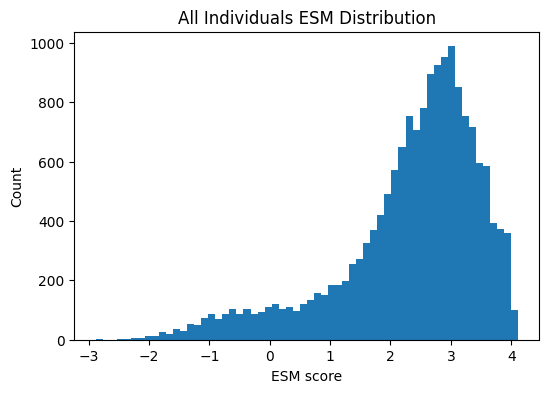

count    16800.000000
mean         2.325460
std          1.190786
min         -2.885480
25%          1.855720
50%          2.610895
75%          3.138274
max          4.116413
Name: ESM, dtype: float64


In [ ]:
df=pd.read_csv("GA_population_history.csv")
print(df["ESM"].describe())


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_population_history.csv")

plt.figure(figsize=(6,4))
plt.hist(df["ESM"], bins=60)
plt.xlabel("ESM score")
plt.ylabel("Count")
plt.title("All Individuals ESM Distribution")
plt.show()

print(df["ESM"].describe())



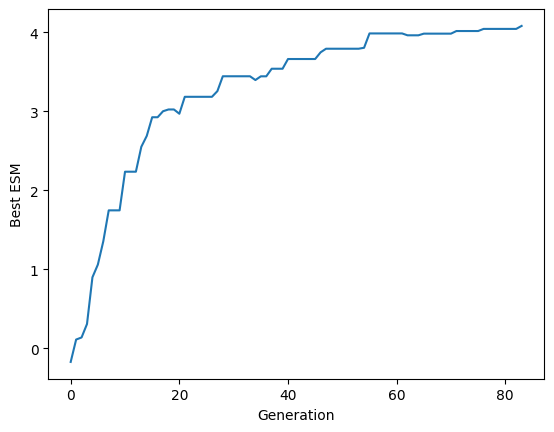

In [4]:
history = pd.read_csv("GA_history.csv")

plt.plot(history["Generation"], history["Best_ESM"])
plt.xlabel("Generation")
plt.ylabel("Best ESM")
plt.show()

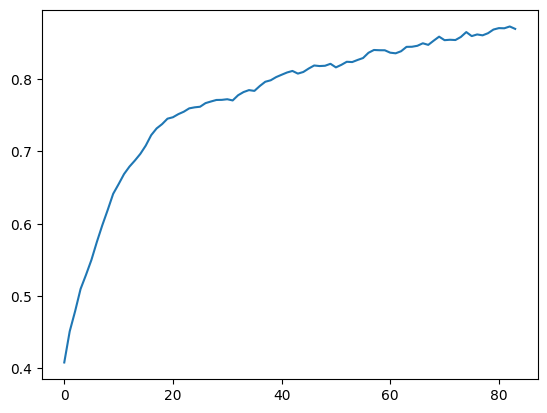

In [5]:
plt.plot(history["Generation"], history["Mean_Fitness"])

#### -3 6,阈值2

count    30000.000000
mean         3.198461
std          1.254803
min         -2.885480
25%          2.704020
50%          3.545509
75%          4.099559
max          4.539017
Name: ESM, dtype: float64


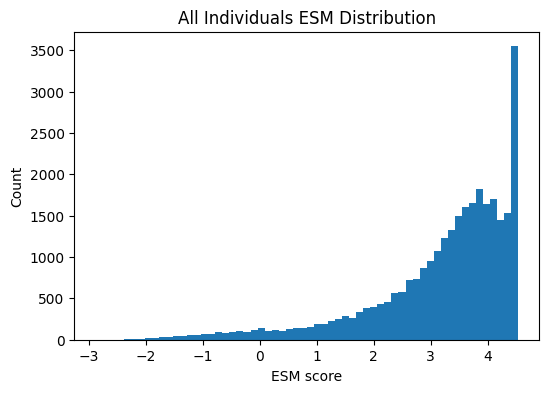

count    30000.000000
mean         3.198461
std          1.254803
min         -2.885480
25%          2.704020
50%          3.545509
75%          4.099559
max          4.539017
Name: ESM, dtype: float64


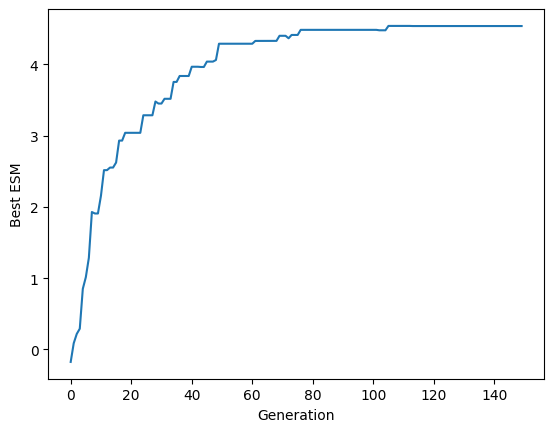

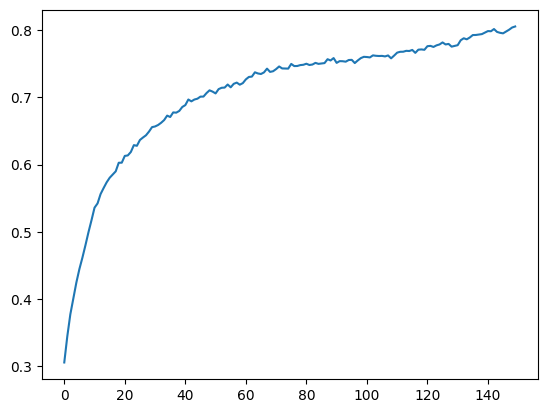

In [3]:
df=pd.read_csv("GA_population_history.csv")
print(df["ESM"].describe())


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_population_history.csv")

plt.figure(figsize=(6,4))
plt.hist(df["ESM"], bins=60)
plt.xlabel("ESM score")
plt.ylabel("Count")
plt.title("All Individuals ESM Distribution")
plt.show()

print(df["ESM"].describe())

history = pd.read_csv("GA_history.csv")

plt.plot(history["Generation"], history["Best_ESM"])
plt.xlabel("Generation")
plt.ylabel("Best ESM")
plt.show()


plt.plot(history["Generation"], history["Mean_Fitness"])

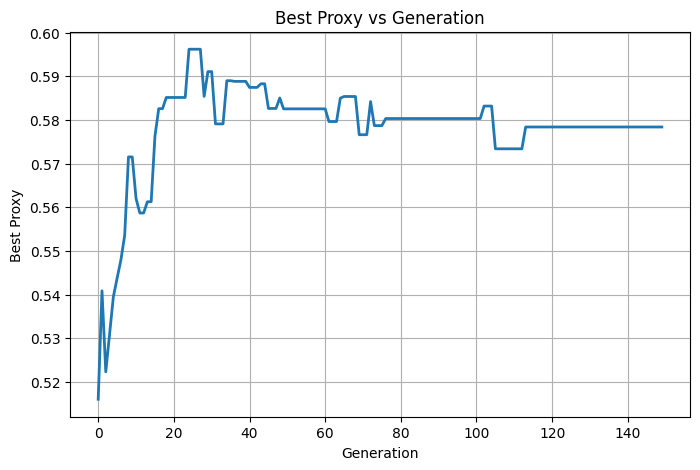

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_history.csv")

plt.figure(figsize=(8,5))
plt.plot(df["Generation"], df["Best_Proxy"], linewidth=2)

plt.xlabel("Generation")
plt.ylabel("Best Proxy")
plt.title("Best Proxy vs Generation")
plt.grid(True)

plt.show()

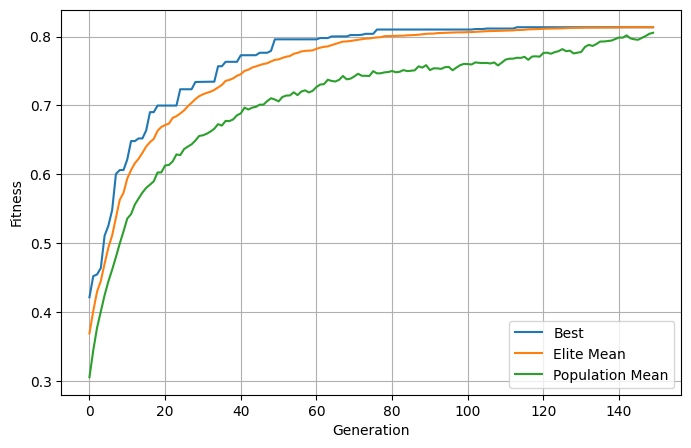

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_history.csv")

plt.figure(figsize=(8,5))

plt.plot(df["Generation"], df["Best_Fitness"], label="Best")
plt.plot(df["Generation"], df["Elite_Fitness"], label="Elite Mean")
plt.plot(df["Generation"], df["Mean_Fitness"], label="Population Mean")

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
print("Initial :", df.iloc[0]["Best_Fitness"])
print("Final   :", df.iloc[-1]["Best_Fitness"])
print("Improve :", df.iloc[-1]["Best_Fitness"]-df.iloc[0]["Best_Fitness"])

Initial : 0.4214377385404084
Final   : 0.8134792775248323
Improve : 0.3920415389844239


#### TOP300

count    60000.000000
mean         3.479458
std          1.167933
min         -2.885480
25%          3.008513
50%          3.787880
75%          4.296348
max          4.922148
Name: ESM, dtype: float64


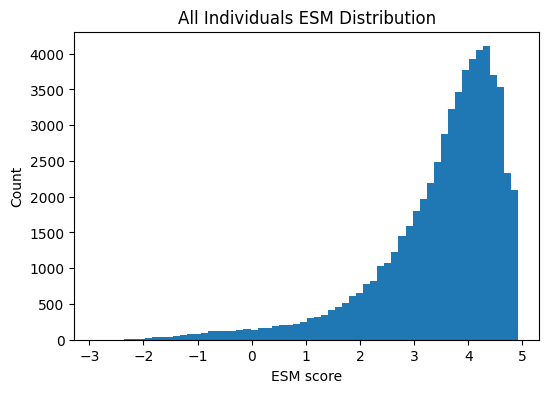

count    60000.000000
mean         3.479458
std          1.167933
min         -2.885480
25%          3.008513
50%          3.787880
75%          4.296348
max          4.922148
Name: ESM, dtype: float64


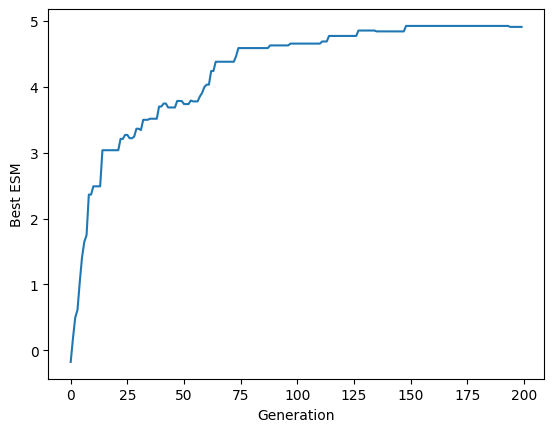

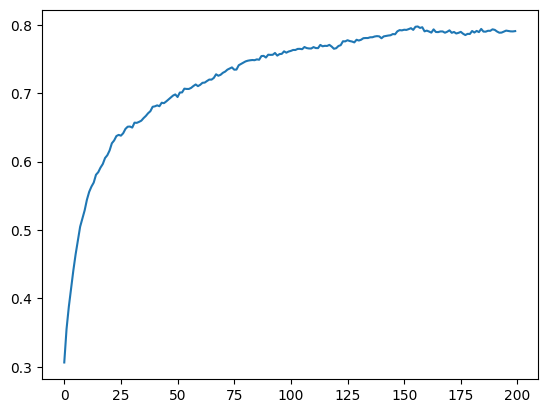

In [3]:
df=pd.read_csv("GA_population_history.csv")
print(df["ESM"].describe())


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_population_history.csv")

plt.figure(figsize=(6,4))
plt.hist(df["ESM"], bins=60)
plt.xlabel("ESM score")
plt.ylabel("Count")
plt.title("All Individuals ESM Distribution")
plt.show()

print(df["ESM"].describe())

history = pd.read_csv("GA_history.csv")

plt.plot(history["Generation"], history["Best_ESM"])
plt.xlabel("Generation")
plt.ylabel("Best ESM")
plt.show()


plt.plot(history["Generation"], history["Mean_Fitness"])

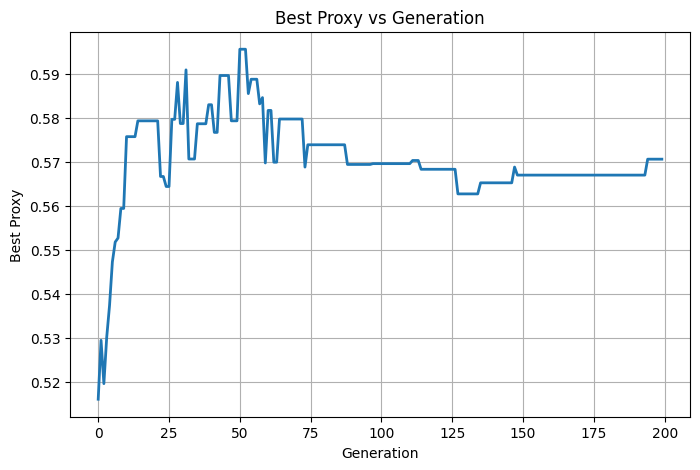

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_history.csv")

plt.figure(figsize=(8,5))
plt.plot(df["Generation"], df["Best_Proxy"], linewidth=2)

plt.xlabel("Generation")
plt.ylabel("Best Proxy")
plt.title("Best Proxy vs Generation")
plt.grid(True)

plt.show()

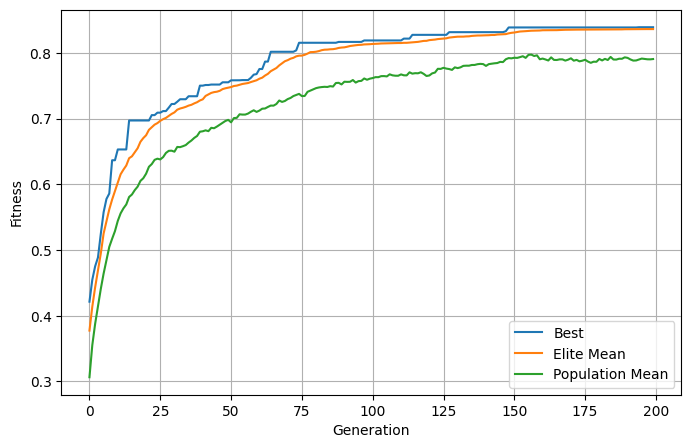

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GA_history.csv")

plt.figure(figsize=(8,5))

plt.plot(df["Generation"], df["Best_Fitness"], label="Best")
plt.plot(df["Generation"], df["Elite_Fitness"], label="Elite Mean")
plt.plot(df["Generation"], df["Mean_Fitness"], label="Population Mean")

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)

plt.show()

## ESM Variant PLL	

In [6]:
import pandas as pd
import torch
from transformers import AutoTokenizer,EsmForMaskedLM
from tqdm import tqdm
import os,re

# =====================================================
# device
# =====================================================
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:",device)

if device.type=="cuda":
    torch.backends.cuda.matmul.allow_tf32=True

# =====================================================
# WT sequence
# =====================================================
wt_seq="MFLRREFGAVAALSVLAHAAPAPAPMQRRDISSTVLDNIDLFAQYSAAAYCSSNIESTGTTLTCDVGNCPLVEAAGATTIDEFDDTSSYGDPTGFIAVDPTNELIVLSFRGSSDLSNWIADLNFGLTSVSSICDGCEMHKGFYEAWEVIADTITSKVEAAVSSYPDYTLVFTGHSYGAALAAVAATVLRNAGYTLDLYNFGQPRIGNLALADYITGQNMGSNYRVTHTDDIVPKLPPELLGYHHFSPEYWITSGNDVTVTTSDVTEVVGVDSTAGNDGTLLDSTTAHRWYTIYISECS"

# =====================================================
# load ESM1v
# =====================================================
model_dir="./esm1v"

if not os.path.exists(model_dir):
    raise FileNotFoundError(model_dir)

tokenizer=AutoTokenizer.from_pretrained(model_dir)

model=EsmForMaskedLM.from_pretrained(model_dir).to(device)

if device.type=="cuda":
    model=model.half()

model.eval()

print("✓ ESM1v loaded")

# =====================================================
# load Top300
# =====================================================
top=pd.read_csv(
    "Top300_GA_ESM_AllGenerations.csv"
)

# 保存GA原始排名
top["GA_Rank"]=top["Rank"]

# =====================================================
# build variant sequence
# =====================================================
def build_variant(mut_string):

    seq=list(wt_seq)

    for m in mut_string.split(";"):

        wt_mut=m.split(">")

        if len(wt_mut)!=2:
            continue

        wt_part=wt_mut[0]
        mut_aa=wt_mut[1]

        pos=int(
            re.findall(
                r"\d+",
                wt_part
            )[0]
        )

        seq[pos-1]=mut_aa

    return "".join(seq)


# =====================================================
# full sequence PLL
# =====================================================
def compute_pll(seq,batch_size=32):

    masked_seqs=[]

    for i in range(len(seq)):

        tmp=list(seq)

        tmp[i]=tokenizer.mask_token

        masked_seqs.append(
            "".join(tmp)
        )

    total_score=0

    for start in range(
        0,
        len(masked_seqs),
        batch_size
    ):

        batch=masked_seqs[start:start+batch_size]

        inputs=tokenizer(
            batch,
            return_tensors="pt",
            padding=True
        )

        inputs={
            k:v.to(device)
            for k,v in inputs.items()
        }

        with torch.no_grad():

            if device.type=="cuda":

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):
                    logits=model(**inputs).logits

            else:
                logits=model(**inputs).logits


        log_probs=torch.log_softmax(
            logits.float(),
            dim=-1
        )

        for j in range(len(batch)):

            seq_pos=start+j

            aa=seq[seq_pos]

            aa_id=tokenizer.convert_tokens_to_ids(
                aa
            )

            score=log_probs[
                j,
                seq_pos+1,
                aa_id
            ]

            total_score+=score.item()

    return total_score/len(seq)


# =====================================================
# WT PLL
# =====================================================
print("\nComputing WT PLL...")

wt_pll=compute_pll(
    wt_seq
)

print(
    f"WT PLL={wt_pll:.4f}"
)


# =====================================================
# variant PLL
# =====================================================
pll=[]
delta=[]
seqs=[]

print("\nComputing variant PLL...")

for muts in tqdm(top["Mutations"]):

    seq=build_variant(
        muts
    )

    seqs.append(seq)

    score=compute_pll(
        seq
    )

    pll.append(score)

    delta.append(
        score-wt_pll
    )


top["Sequence"]=seqs
top["WT_PLL"]=wt_pll
top["ESM_PLL"]=pll
top["Delta_PLL"]=delta


# =====================================================
# normalize Delta PLL
# =====================================================
top["Delta_PLL_norm"]=(
    top["Delta_PLL"]
    -
    top["Delta_PLL"].min()
)/(
    top["Delta_PLL"].max()
    -
    top["Delta_PLL"].min()
    +
    1e-8
)


# =====================================================
# sort by PLL
# =====================================================
top=top.sort_values(
    "ESM_PLL",
    ascending=False
).reset_index(drop=True)


top.insert(
    0,
    "PLL_Rank",
    range(
        1,
        len(top)+1
    )
)


# =====================================================
# save
# =====================================================
out_file="Top300_ESM_PLL_ranked.csv"

top.to_csv(
    out_file,
    index=False
)


print("\nTop10:")
print(
    top[
        [
            "PLL_Rank",
            "GA_Rank",
            "Fitness",
            "ESM_PLL",
            "Delta_PLL",
            "Mutations"
        ]
    ].head(10)
)


print("\nFinished")
print(
    "Saved:",
    out_file
)

/home/rduser/envs/pla/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at ./esm1v and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ ESM1v loaded

Computing WT PLL...
WT PLL=-1.5286

Computing variant PLL...


100%|██████████| 300/300 [20:58<00:00,  4.19s/it]


Top10:
   PLL_Rank  GA_Rank   Fitness   ESM_PLL  Delta_PLL  \
0         1      246  0.827253 -1.220637   0.307981   
1         2       15  0.836415 -1.221688   0.306930   
2         3      186  0.828465 -1.221767   0.306851   
3         4       37  0.833962 -1.222709   0.305909   
4         5        5  0.837348 -1.223412   0.305206   
5         6       79  0.831663 -1.223630   0.304988   
6         7       45  0.833598 -1.223797   0.304821   
7         8       12  0.836697 -1.224383   0.304235   
8         9       27  0.834725 -1.224543   0.304075   
9        10       61  0.832716 -1.225730   0.302887   

                                           Mutations  
0  5R>S;6E>S;8G>A;18H>S;39I>L;92P>T;100P>S;103E>K...  
1  5R>S;6E>L;18H>S;26M>L;39I>L;92P>T;100P>S;103E>...  
2  3L>S;5R>S;6E>L;26M>L;39I>L;92P>T;100P>S;103E>K...  
3  5R>S;6E>L;18H>S;26M>L;39I>L;92P>T;100P>S;103E>...  
4  5R>S;6E>L;18H>S;26M>L;39I>L;92P>T;100P>S;103E>...  
5  5R>S;6E>L;18H>S;39I>L;92P>T;100P>S;103E>K;115L...  
6

## ASR-ESM

In [1]:
import torch
import pandas as pd
from transformers import AutoTokenizer, EsmForMaskedLM
import os

# ==========================================================
# Step1. 加载ESM-1v
# ==========================================================

model_dir = "./esm1v"

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = EsmForMaskedLM.from_pretrained(model_dir)
model.eval()

print("Model loaded.")

# ==========================================================
# Step2. WT & ASR
# ==========================================================

wt_seq = "MFLRREFGAVAALSVLAHAAPAPAPMQRRDISSTVLDNIDLFAQYSAAAYCSSNIESTGTTLTCDVGNCPLVEAAGATTIDEFDDTSSYGDPTGFIAVDPTNELIVLSFRGSSDLSNWIADLNFGLTSVSSICDGCEMHKGFYEAWEVIADTITSKVEAAVSSYPDYTLVFTGHSYGAALAAVAATVLRNAGYTLDLYNFGQPRIGNLALADYITGQNMGSNYRVTHTDDIVPKLPPELLGYHHFSPEYWITSGNDVTVTTSDVTEVVGVDSTAGNDGTLLDSTTAHRWYTIYISECS"

asr_seq = "MFLRRLFGVVAALAVLAHAAAAPAPLERRDVSSDLLDQLDLFAQYSAAAYCSSNLNSAGTTVTCSAGNCPLVEAANTTTLYEFDDTSSYGDTTGFLAVDSTNKLIVLSFRGSSSLENWIADLDFGLVDASSICNGCEVHKGFWESWNSVADTLTSKIESAVNAYPDYSLVFTGHSLGGALATLGATVLRNAGYNVDLYTYGCPRVGNTALADYITNQSSGSNYRVTHTDDVVPKLPPRLLGYSQPSPEYWITSGNDVTVTTSDIEVIEGVDSTAGNAGTAAASIDAHRWYFINISACS"

assert len(wt_seq) == len(asr_seq)

# ==========================================================
# Step3. ESM score
# ==========================================================

def esm_score(wt_seq, pos, mut_aa):

    seq = list(wt_seq)

    wt_aa = seq[pos]

    seq[pos] = tokenizer.mask_token

    masked_seq = "".join(seq)

    inputs = tokenizer(masked_seq, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    log_probs = torch.log_softmax(outputs.logits, dim=-1)

    mask_idx = torch.where(
        inputs["input_ids"][0] == tokenizer.mask_token_id
    )[0].item()

    wt_id = tokenizer.convert_tokens_to_ids(wt_aa)
    mut_id = tokenizer.convert_tokens_to_ids(mut_aa)

    delta = (
        log_probs[0, mask_idx, mut_id]
        -
        log_probs[0, mask_idx, wt_id]
    ).item()

    return delta

# ==========================================================
# Step4. Compare WT and ASR
# ==========================================================

results = []

total = 0

for pos, (wt, mut) in enumerate(zip(wt_seq, asr_seq), start=1):

    if wt == mut:
        continue

    total += 1

    delta = esm_score(
        wt_seq,
        pos - 1,
        mut
    )

    results.append({

        "Position": pos,

        "WT": wt,

        "Mut": mut,

        "Delta_logP": delta

    })

    print(f"{pos:3d}: {wt}->{mut}  ΔlogP={delta:.3f}")

print()

print("Total ASR mutations:", total)

# ==========================================================
# Step5. Save
# ==========================================================

df = pd.DataFrame(results)

df = df.sort_values(
    "Delta_logP",
    ascending=False
)

df["Rank"] = range(1, len(df)+1)

df.to_csv(
    "ASR_ESM_scores.csv",
    index=False
)

print(df.head(20))

print()

print("Saved -> ASR_ESM_scores.csv")

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 538/538 [00:00<00:00, 12505.32it/s]
EsmForMaskedLM LOAD REPORT from: ./esm1v
Key                                | Status     | 
-----------------------------------+------------+-
esm.embeddings.position_ids        | UNEXPECTED | 
esm.contact_head.regression.bias   | MISSING    | 
esm.contact_head.regression.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
  6: E->L  ΔlogP=5.616
  9: A->V  ΔlogP=-0.558
 14: S->A  ΔlogP=1.576
 21: P->A  ΔlogP=-2.768
 26: M->L  ΔlogP=3.150
 27: Q->E  ΔlogP=0.211
 31: I->V  ΔlogP=-0.012
 34: T->D  ΔlogP=0.919
 35: V->L  ΔlogP=0.430
 38: N->Q  ΔlogP=1.344
 39: I->L  ΔlogP=2.514
 55: I->L  ΔlogP=-0.285
 56: E->N  ΔlogP=0.482
 58: T->A  ΔlogP=0.138
 62: L->V  ΔlogP=0.563
 65: D->S  ΔlogP=0.633
 66: V->A  ΔlogP=1.908
 76: G->N  ΔlogP=-0.871
 77: A->T  ΔlogP=-0.819
 80: I->L  ΔlogP=-0.372
 81: D->Y  ΔlogP=-0.329
 92: P->T  ΔlogP=5.015
 96: I->L  ΔlogP=-1.963
100: P->S  ΔlogP=2.661
103: E->K  ΔlogP=3.006
114: D->S  ΔlogP=1.034
116: S->E  ΔlogP=-0.275
123: N->D  ΔlogP=0.864
127: T->V  ΔlogP=-2.560
128: S->D  ΔlogP=1.513
129: V->A  ΔlogP=1.404
134: D->N  ΔlogP=-1.819
138: M->V  ΔlogP=7.381
143: Y->W  ΔlogP=0.578
145: A->S  ΔlogP=0.754
147: E->N  ΔlogP=-0.187
148: V->S  ΔlogP=2.228
149: I->V  ΔlogP=1.250
153: I->L  ΔlogP=-0.780
157: V->I  ΔlogP=-1.567
159: A->S  ΔlogP=1.714
162: S->N  ΔlogP=-2.451
163:

In [11]:
import pandas as pd

# ===========================================
# 读取文件
# ===========================================

asr_df = pd.read_csv("ASR_ESM_scores.csv")

entropy_df = pd.read_csv("3k_mutation_5_candidates.csv")

# ===========================================
# 列名统一
# ===========================================

entropy_df = entropy_df.rename(columns={
    "Real_Pos": "Position"
})

# ===========================================
# 只保留需要的列
# ===========================================

entropy_df = entropy_df[[
    "Position",
    "Alignment_Pos",
    "Entropy",
    "Top_mutations"
]]

# ===========================================
# 合并
# ===========================================

asr_df = pd.merge(
    asr_df,
    entropy_df,
    on="Position",
    how="left"
)

# ===========================================
# 保存
# ===========================================

asr_df.to_csv(
    "ASR_ESM_scores_with_entropy.csv",
    index=False
)

print(asr_df.head())

   Position WT Mut  Delta_logP  Rank  Alignment_Pos   Entropy  \
0       176  Y   L    8.620511     1           6554  0.821826   
1       138  M   V    7.381480     2           6187  1.654679   
2         6  E   L    5.616456     3           2793  2.482578   
3        92  P   T    5.015179     4           5216  2.413332   
4       219  M   S    3.491039     5           7050  1.024373   

               Top_mutations  
0  ['L', 'F', 'M', 'I', 'V']  
1  ['V', 'A', 'I', 'L', 'S']  
2  ['S', 'R', 'L', 'K', 'Q']  
3  ['S', 'T', 'V', 'I', 'A']  
4  ['Q', 'K', 'S', 'A', 'P']  


- 读取 final_mutation_1.0_table.xlsx
- 读取 ASR_ESM_scores_with_entropy.csv
- 合并两个突变池（不是 merge，而是 concat）
- 添加 Source
- 0：仅来自 final_mutation_1.0_table
- 1：仅来自 ASR
- 2：两个文件都有
- 删除重复突变（Position+WT+Mut）
- 重新计算 Rank（按照整个突变池的 Delta_logP）
- 最后按 Position、Delta_logP 排序
- 输出 Excel

In [15]:
import pandas as pd

# ==========================================================
# Step 1. 读取文件
# ==========================================================

df_final = pd.read_csv("final_mutation_all_table.csv")
df_asr = pd.read_csv("ASR_ESM_scores_with_entropy.csv")

# ==========================================================
# Step 2. 标记来源
# ==========================================================

df_final["Source"] = 0
df_asr["Source"] = 1

# ==========================================================
# Step 3. 拼接
# ==========================================================

merged = pd.concat(
    [df_final, df_asr],
    ignore_index=True
)

# ==========================================================
# Step 4. 找出两个文件共有的突变
# Position + WT + Mut 相同认为是同一个突变
# ==========================================================

dup = merged.duplicated(
    subset=["Position", "WT", "Mut"],
    keep=False
)

merged.loc[dup, "Source"] = 2

# ==========================================================
# Step 5. 删除重复
# 保留第一条即可（两条内容理论上相同）
# ==========================================================

merged = merged.drop_duplicates(
    subset=["Position", "WT", "Mut"],
    keep="first"
)

# ==========================================================
# Step 6. 重新计算Rank（整个突变池）
# ==========================================================

merged["Rank"] = (
    merged["Delta_logP"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# ==========================================================
# Step 7. 排序
# ==========================================================

merged = merged.sort_values(
    "Delta_logP",
    ascending=False
)

# ==========================================================
# Step 8. 调整列顺序（如果存在这些列）
# ==========================================================

column_order = [
    "Position",
    "WT",
    "Mut",
    "Delta_logP",
    "Rank",
    "Alignment_Pos",
    "Entropy",
    "Top_mutations",
    "BLOSUM",
    "BioBonus",
    "ESM_norm",
    "Entropy_norm",
    "BLOSUM_norm",
    "BioBonus_norm",
    "ProxyScore",
    "Source"
]

# 只保留实际存在的列，避免报错
column_order = [c for c in column_order if c in merged.columns]

merged = merged[column_order]

# ==========================================================
# Step 9. 保存
# ==========================================================

merged.to_csv(
    "Merged_mutation_table.csv",
    index=False
)

# ==========================================================
# Step 10. 输出统计
# ==========================================================

print("=" * 60)
print("Merged mutation pool saved.")
print()

print("Source statistics:")
print("0 = Final only")
print("1 = ASR only")
print("2 = Shared")
print()

print(merged["Source"].value_counts().sort_index())

print()

print("Total mutations:", len(merged))

Merged mutation pool saved.

Source statistics:
0 = Final only
1 = ASR only
2 = Shared

Source
0    1418
1       7
2      71
Name: count, dtype: int64

Total mutations: 1496


## make pic

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10808\598597316.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


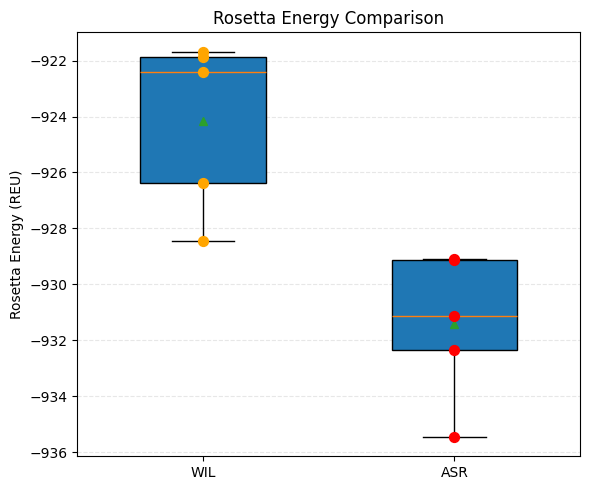

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Data
# =========================
WT = [-928.467, -926.383, -922.423, -921.867, -921.677]
ASR = [-935.460, -932.351, -931.121, -929.122, -929.108]

# =========================
# Boxplot
# =========================
plt.figure(figsize=(6,5))

plt.boxplot(
    [WT, ASR],
    labels=["WIL", "ASR"],
    patch_artist=True,
    widths=0.5,
    showmeans=True
)

# =========================
# Scatter points
# =========================
colors = ["orange", "red"]

for i, (data, c) in enumerate(zip([WT, ASR], colors), start=1):
    x = [i] * len(data)
    plt.scatter(
        x,
        data,
        s=50,
        color=c,
        zorder=3
    )

# =========================
# Figure settings
# =========================
plt.ylabel("Rosetta Energy (REU)")
plt.title("Rosetta Energy Comparison")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()